In [1]:
import os
import gc
from pathlib import Path
from collections import Counter

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
## Import AnnData Object ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Create Pseudobulk Col ##

adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [4]:
## Known Genes In Deleted Regions ##

# https://bioinfo.uth.edu/SZGR/display/showGeneset #

CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

ALL_22q11 = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
                    "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "MAPK1", "HIRA", "ZNF74", "CLTCL1",
                    "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
                    "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
                    "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
                    "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
                    "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
                    "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
                    "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
                    "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
                    "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
                    "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
                    "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
                    "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
                    "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
                    "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
                    "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
                    "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
                    "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
                    "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
                    "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
                    "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
                    "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [5]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [6]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29
}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [7]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [8]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [9]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [10]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [11]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [12]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5848214285714286

In [13]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7361477572559367

In [14]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.7441860465116279

In [15]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    457
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    112
Hindbrain Neurons NR2F2+PBX3+LHX1+              48
Proliferative Radial Glia SOX2+HES6+TOP2A+      32
Radial Glia SOX2+PAX6+FABP7+                     4
Mixed Neurons FGF12+GRIN2B+CAMK2B+               2
Name: count, dtype: int64

In [16]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     2
Name: count, dtype: int64

In [17]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    353
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     22
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [19]:
## Check Overlap Between Directionally Consistent MetaAnalyzed DataFrames ##

df_22q11_to_merge = dc_significant_22q11_df_logfc.copy()
df_22q11_to_merge.columns = [i+'_22q11' for i in df_22q11_to_merge.columns]

df_nrxn1_to_merge = dc_significant_nrxn1_df_logfc.copy()
df_nrxn1_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_to_merge.columns]

df_idiopathic_to_merge = dc_significant_idiopathic_df_logfc.copy()
df_idiopathic_to_merge.columns = [i+'_idiopathic' for i in dc_significant_idiopathic_df_logfc.columns]

df_22q11_nrxn1 = df_22q11_to_merge.merge(df_nrxn1_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic = df_22q11_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic = df_nrxn1_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

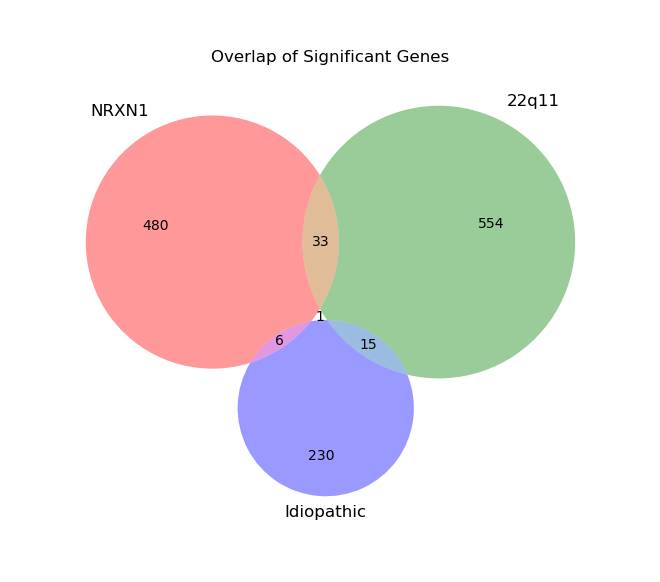

In [20]:
## Venn Diagram Of Overlap CellType Agonstic ##

# Convert your lists to sets
dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# --- Venn diagram for all three lists ---
plt.figure(figsize=(8, 6))
venn3([dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
      set_labels=('NRXN1', '22q11', 'Idiopathic'))
plt.title("Overlap of Significant Genes")
plt.show()

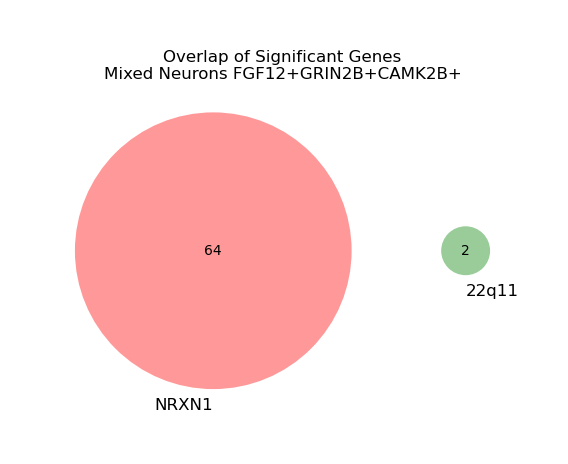

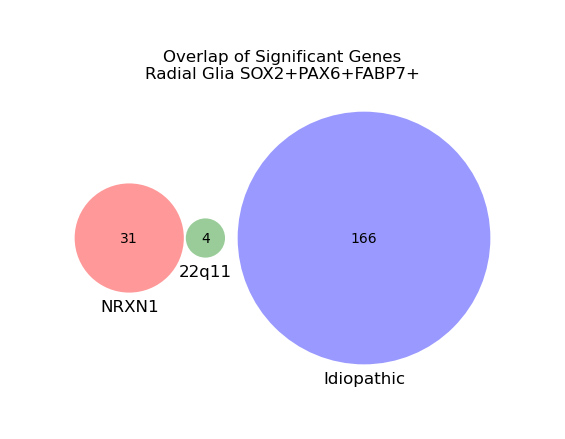

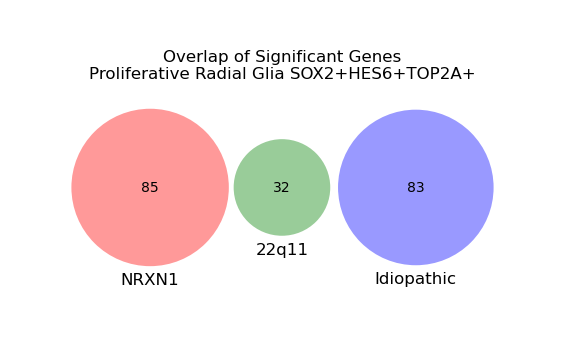

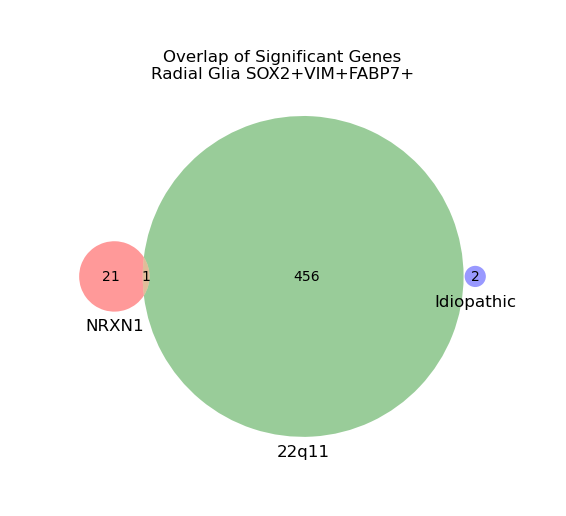

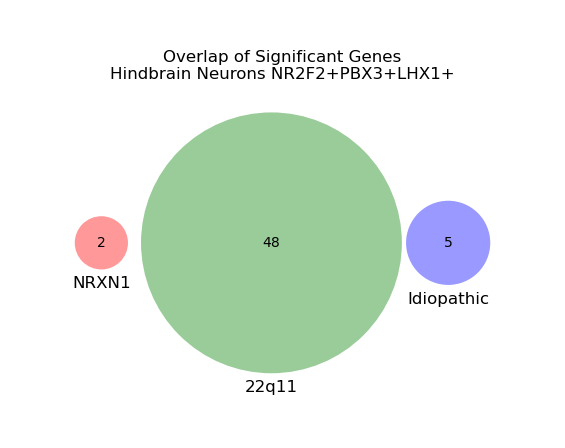

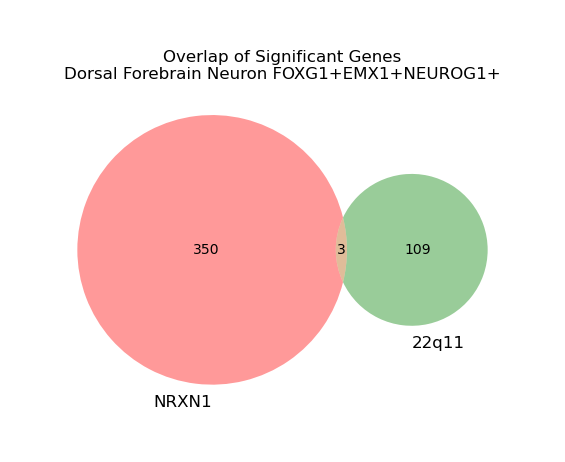

In [75]:
## Venn Diagram Of Overlap CellType Specific ##

# get all unique assays
assays = set(dc_significant_nrxn1_df_logfc['assay']) \
    | set(dc_significant_22q11_df_logfc['assay']) \
    | set(dc_significant_idiopathic_df_logfc['assay'])

for assay in assays:

    nrxn1_genes = set(dc_significant_nrxn1_df_logfc.loc[dc_significant_nrxn1_df_logfc['assay'] == assay, 'ID'])

    q22_genes = set(dc_significant_22q11_df_logfc.loc[dc_significant_22q11_df_logfc['assay'] == assay, 'ID'])

    idiopathic_genes = set(dc_significant_idiopathic_df_logfc.loc[dc_significant_idiopathic_df_logfc['assay'] == assay, 'ID'])

    sets = [('NRXN1', nrxn1_genes), ('22q11', q22_genes), ('Idiopathic', idiopathic_genes)]

    # keep only non-empty sets
    non_empty = [(name, s) for name, s in sets if len(s) > 0]

    # skip if fewer than 2 sets
    if len(non_empty) < 2:
        continue

    plt.figure(figsize=(6, 5))

    if len(non_empty) == 3:
        venn3([s for _, s in non_empty],
              set_labels=[n for n, _ in non_empty])

    elif len(non_empty) == 2:
        venn2([s for _, s in non_empty],
              set_labels=[n for n, _ in non_empty])

    plt.title(f"Overlap of Significant Genes\n{assay}")
    safe_assay = assay.replace(" ", "_").replace("+", "").replace("/", "_")
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/{safe_assay}_venn.svg", bbox_inches='tight')
    plt.show()

In [22]:
df_22q11_nrxn1[[i for i in df_22q11_nrxn1.columns if ('logFC' in i) or ('assay' in i)]]

## Theres only 4 instances across 2 celltypes when a gene is directionally shared across all manuscripts and significant ##
## In all of those intsances the signs are changed ##

,assay_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,assay_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.810193,-0.437400,-0.550054,-0.599216,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.097236,0.485237,0.291237
1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.567551,-0.055408,-0.592939,-0.405299,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.253811,-1.403265,-0.828538
2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.348741,-0.126931,-0.756534,-0.410735,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.351464,-0.765686,-0.558575
3,Radial Glia SOX2+VIM+FABP7+,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.351354,-1.405320,-1.151581,-0.969418,Radial Glia SOX2+VIM+FABP7+,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.284833,1.638557,0.961695


In [23]:
df_22q11_nrxn1[[i for i in df_22q11_nrxn1.columns if ('logFC' in i) or ('ID' in i)]]

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.810193,-0.437400,-0.550054,-0.599216,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.097236,0.485237,0.291237
1,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.567551,-0.055408,-0.592939,-0.405299,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.253811,-1.403265,-0.828538
2,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.348741,-0.126931,-0.756534,-0.410735,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.351464,-0.765686,-0.558575
3,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.351354,-1.405320,-1.151581,-0.969418,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.284833,1.638557,0.961695


In [24]:
df_22q11_idiopathic

,ID_22q11,assay_22q11,estimate_22q11,std.error_22q11,statistic_22q11,p.value_22q11,n.studies_22q11,method_22q11,assay_ID_22q11,p.adjusted_22q11,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [25]:
df_nrxn1_idiopathic

,ID_nrxn1,assay_nrxn1,estimate_nrxn1,std.error_nrxn1,statistic_nrxn1,p.value_nrxn1,n.studies_nrxn1,method_nrxn1,assay_ID_nrxn1,p.adjusted_nrxn1,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [26]:
## Identify Genes Across Disease That May Not be Directionally Consistent Within a Disease, but Significant Within and Across Dx ##

df_22q11_non_dc_to_merge = significant_22q11_df_logfc.copy()
df_22q11_non_dc_to_merge.columns = [i+'_22q11' for i in df_22q11_non_dc_to_merge.columns]

df_nrxn1_non_dc_to_merge = significant_nrnx1_df_logfc.copy()
df_nrxn1_non_dc_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_non_dc_to_merge.columns]

df_idiopathic_non_dc_to_merge = significant_idiopathic_df_logfc.copy()
df_idiopathic_non_dc_to_merge.columns = [i+'_idiopathic' for i in df_idiopathic_non_dc_to_merge.columns]

df_22q11_nrxn1_non_dc = df_22q11_non_dc_to_merge.merge(df_nrxn1_non_dc_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic_non_dc = df_22q11_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic_non_dc = df_nrxn1_non_dc_to_merge.merge(df_idiopathic_non_dc_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

In [27]:
df_22q11_nrxn1_non_dc[[i for i in df_22q11_nrxn1_non_dc.columns if ('logFC' in i) or ('ID' in i)]]

## if you lax the constraints to take things thta dont have full directional consistency, you can get a few extra hits ##
## one of which has NRXN1 22q11.2 deletion mixup ## Nothing Shared with Idiopathic ##

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,BTRC,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.400437,0.117907,-1.018074,-0.433535,BTRC,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.043618,-0.926473,-0.485045
1,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.810193,-0.437400,-0.550054,-0.599216,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.097236,0.485237,0.291237
2,FXYD1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.967655,1.000191,-0.203792,-0.057086,FXYD1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.095041,-1.217400,-0.656220
3,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.769505,0.018374,0.878750,0.555543,GOLGA8B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.284653,-1.045595,-0.380471
4,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.567551,-0.055408,-0.592939,-0.405299,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.253811,-1.403265,-0.828538
5,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.348741,-0.126931,-0.756534,-0.410735,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.351464,-0.765686,-0.558575
6,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.351354,-1.405320,-1.151581,-0.969418,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.284833,1.638557,0.961695


In [28]:
df_22q11_idiopathic_non_dc

,ID_22q11,assay_22q11,estimate_22q11,std.error_22q11,statistic_22q11,p.value_22q11,n.studies_22q11,method_22q11,assay_ID_22q11,p.adjusted_22q11,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [29]:
df_nrxn1_idiopathic_non_dc

,ID_nrxn1,assay_nrxn1,estimate_nrxn1,std.error_nrxn1,statistic_nrxn1,p.value_nrxn1,n.studies_nrxn1,method_nrxn1,assay_ID_nrxn1,p.adjusted_nrxn1,...,p.value_idiopathic,n.studies_idiopathic,method_idiopathic,assay_ID_idiopathic,p.adjusted_idiopathic,significant_fdr_idiopathic,logFC_sawada_idiopathic,logFC_notaras_idiopathic,directionally_consistent_idiopathic,mean_logFC_idiopathic


In [30]:
## What if it was enough that a single gene was showing up in multiple different disease in the same direction ideally ##

sig_22q11_idiopathic_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_idiopathic_df_logfc['ID'])

sig_22q11_nrxn1_set = set(dc_significant_22q11_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

sig_idiopathic_nrxn1_set = set(dc_significant_idiopathic_df_logfc['ID']).intersection(dc_significant_nrxn1_df_logfc['ID'])

In [31]:
dc_significant_all = pd.concat([dc_significant_idiopathic_df_logfc.assign(group='Idiopathic Schizophrenia'),
                                dc_significant_nrxn1_df_logfc.assign(group='NRXN1del'), 
                                dc_significant_22q11_df_logfc.assign(group='22q11.2del')], axis=0)

In [32]:
dc_significant_all[dc_significant_all['ID'].isin(sig_22q11_idiopathic_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
15,ARL5B,Radial Glia SOX2+PAX6+FABP7+,0.593515,0.209138,2.837905,4.541065e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | ARL5B,0.026245,...,0.444488,0.712637,True,0.578563,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
43,BTG3,Radial Glia SOX2+PAX6+FABP7+,-0.723234,0.225533,-3.206784,1.342279e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | BTG3,0.01039,...,-0.410922,-1.012575,True,-0.711748,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
69,CNOT1,Radial Glia SOX2+PAX6+FABP7+,0.660485,0.195281,3.382234,7.189898e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | CNOT1,0.006441,...,0.254040,0.898589,True,0.576314,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
81,CSTF2T,Radial Glia SOX2+PAX6+FABP7+,-0.709228,0.202929,-3.494964,4.741252e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | CSTF2T,0.004607,...,-0.338200,-0.862699,True,-0.600450,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
117,FGFR3,Radial Glia SOX2+PAX6+FABP7+,0.949626,0.301747,3.147093,1.649026e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | FGFR3,0.012185,...,1.289521,0.809575,True,1.049548,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
147,IFT81,Radial Glia SOX2+PAX6+FABP7+,-0.719243,0.263185,-2.732840,6.279074e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | IFT81,0.033416,...,-0.128751,-1.347612,True,-0.738181,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
148,IFT88,Radial Glia SOX2+PAX6+FABP7+,-1.046169,0.287025,-3.644866,2.675316e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | IFT88,0.002938,...,-0.579234,-1.481278,True,-1.030256,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
179,NAE1,Radial Glia SOX2+PAX6+FABP7+,-0.588743,0.201519,-2.921522,3.483255e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | NAE1,0.021367,...,-0.194280,-0.797137,True,-0.495708,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
197,NUFIP2,Radial Glia SOX2+PAX6+FABP7+,0.658346,0.191864,3.431321,6.006503e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | NUFIP2,0.005615,...,0.050674,1.040951,True,0.545812,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
206,PCGF5,Radial Glia SOX2+PAX6+FABP7+,-0.671878,0.219370,-3.062763,2.193037e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | PCGF5,0.014942,...,-0.738346,-0.608290,True,-0.673318,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN


In [33]:
dc_significant_all[dc_significant_all['ID'].isin(sig_22q11_nrxn1_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
333,WWC2,Radial Glia SOX2+PAX6+FABP7+,0.716472,0.222280,3.223286,1.267291e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | WWC2,0.009917,...,0.441549,0.888741,True,0.665145,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
11,ACTL6B,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.385863,0.335756,4.127585,3.665926e-05,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | A...,0.007528,...,NaN,NaN,True,1.491331,NRXN1del,0.730682,2.251980,NaN,NaN,NaN
57,ATP9A,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.716260,0.143636,-4.986653,6.143427e-07,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.000079,...,NaN,NaN,True,-0.573033,NRXN1del,-0.336721,-0.809346,NaN,NaN,NaN
58,ATP9A,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.615183,0.122124,-5.037358,4.720009e-07,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | A...,0.000232,...,NaN,NaN,True,-0.708816,NRXN1del,-0.376014,-1.041618,NaN,NaN,NaN
87,CCDC144A,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.626374,0.174903,-3.581270,3.419280e-04,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | C...,0.045318,...,NaN,NaN,True,-0.711227,NRXN1del,-0.317460,-1.104995,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012,TRAPPC6A,Radial Glia SOX2+VIM+FABP7+,0.289561,0.100363,2.885148,3.912297e-03,3,FE,Radial Glia SOX2+VIM+FABP7+ | TRAPPC6A,0.04904,...,NaN,NaN,True,0.396555,22q11.2del,NaN,NaN,0.065684,0.784151,0.339829
1013,TRIAP1,Radial Glia SOX2+VIM+FABP7+,-0.380684,0.093322,-4.079267,4.517796e-05,3,FE,Radial Glia SOX2+VIM+FABP7+ | TRIAP1,0.002103,...,NaN,NaN,True,-0.313747,22q11.2del,NaN,NaN,-0.304870,-0.447237,-0.189134
1033,TTC9B,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.410177,0.114184,-3.592254,3.278305e-04,3,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.022611,...,NaN,NaN,True,-0.350485,22q11.2del,NaN,NaN,-0.358190,-0.086868,-0.606398
1055,WWC2,Radial Glia SOX2+VIM+FABP7+,0.574878,0.137773,4.172658,3.010671e-05,3,FE,Radial Glia SOX2+VIM+FABP7+ | WWC2,0.001571,...,NaN,NaN,True,0.689373,22q11.2del,NaN,NaN,0.421557,0.609058,1.037503


In [34]:
dc_significant_all[dc_significant_all['ID'].isin(sig_idiopathic_nrxn1_set)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
109,ERP29,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.623649,0.200056,3.117367,1.824741e-03,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | E...,0.016097,...,0.575010,0.689993,True,0.632501,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
125,GMNN,Radial Glia SOX2+PAX6+FABP7+,-0.830328,0.205176,-4.046906,5.189914e-05,2,FE,Radial Glia SOX2+PAX6+FABP7+ | GMNN,0.000812,...,-0.233035,-1.160199,True,-0.696617,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
133,GTF2H2,Radial Glia SOX2+PAX6+FABP7+,-0.728649,0.202898,-3.591212,3.291439e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | GTF2H2,0.00349,...,-0.004402,-1.463980,True,-0.734191,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
173,MID1IP1,Radial Glia SOX2+PAX6+FABP7+,0.655463,0.191980,3.414226,6.396339e-04,2,FE,Radial Glia SOX2+PAX6+FABP7+ | MID1IP1,0.005852,...,0.296491,0.887862,True,0.592176,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
175,MPP5,Proliferative Radial Glia SOX2+HES6+TOP2A+,-0.896524,0.255693,-3.506252,4.544641e-04,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | MPP5,0.005541,...,-0.554074,-1.111785,True,-0.832929,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
314,TUBB6,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.690278,0.222506,3.102287,1.920318e-03,2,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | T...,0.016658,...,0.120544,1.299349,True,0.709946,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
333,WWC2,Radial Glia SOX2+PAX6+FABP7+,0.716472,0.222280,3.223286,1.267291e-03,2,FE,Radial Glia SOX2+PAX6+FABP7+ | WWC2,0.009917,...,0.441549,0.888741,True,0.665145,Idiopathic Schizophrenia,NaN,NaN,NaN,NaN,NaN
214,ERP29,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.259278,0.082906,3.127363,1.763822e-03,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.043564,...,NaN,NaN,True,0.259939,NRXN1del,0.086583,0.433295,NaN,NaN,NaN
263,GMNN,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.668975,0.168104,3.979530,6.905160e-05,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.004064,...,NaN,NaN,True,0.451829,NRXN1del,0.025422,0.878236,NaN,NaN,NaN
281,GTF2H2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.441846,0.119581,3.694948,2.199317e-04,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.009393,...,NaN,NaN,True,0.383241,NRXN1del,0.111348,0.655134,NaN,NaN,NaN


In [35]:
def plot_count_strip(values, orientation="horizontal", cmap="Reds", figsize=None, dataset_label='',
                     annotate=True, vmin=None, vmax=None, cbar=True, save=False):
    
    values = np.array(values)
    
    if orientation == "horizontal":
        data = values.reshape(1, -1)
        if figsize is None:
            figsize = (len(values) * 0.4, 1.5)
        xticklabels = False
        yticklabels = False
        
    elif orientation == "vertical":
        data = values.reshape(-1, 1)
        if figsize is None:
            figsize = (1.5, len(values) * 0.4)
        xticklabels = False
        yticklabels = False
        
    else:
        raise ValueError("orientation must be 'horizontal' or 'vertical'")
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(data, cmap=cmap, cbar=cbar, annot=annotate, fmt=".0f", xticklabels=xticklabels, 
                yticklabels=yticklabels, vmin=vmin, vmax=vmax)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/{dataset_label}_{orientation}_upset_heatmap.svg")
    
    plt.show()

In [36]:
def plot_assay_upset(df, set_col='group', gene_col='ID', significance_col='significant_fdr', 
                     min_size=1, dataset_label="", top_graph=True, side_graph=True, title=True, 
                     save=False):

    # filter significant genes
    if significance_col in df.columns:
        df = df[df[significance_col] == True]
    
    assay_sets = {val: set(group[gene_col].dropna().unique())
        for val, group in df.groupby(set_col)}
    
    # remove small sets
    assay_sets = {k: v for k, v in assay_sets.items() if len(v) >= min_size}
    
    # safety check
    if len(assay_sets) < 2:
        print(f"Not enough groups to plot: {list(assay_sets.keys())}")
        return
    
    # convert
    upset_data = from_contents(assay_sets)
    
    plt.figure(figsize=(10, 6))

    if top_graph and side_graph:
        upset = UpSet(upset_data, show_counts=True, sort_by='degree')
    elif top_graph and not side_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, totals_plot_elements=0)
    elif side_graph and not top_graph:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=())
    else:
        upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
    
    upset.plot()

    if title:
        plt.suptitle(f"{dataset_label} Shared DGEs")
        
    if save:
        plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/{dataset_label}_upset_.svg")
    
    plt.show()

In [37]:
dc_significant_all['group'].value_counts()

group
22q11.2del                  655
NRXN1del                    558
Idiopathic Schizophrenia    256
Name: count, dtype: int64

In [38]:
dc_significant_all['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    481
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    465
Radial Glia SOX2+PAX6+FABP7+                   201
Proliferative Radial Glia SOX2+HES6+TOP2A+     200
Mixed Neurons FGF12+GRIN2B+CAMK2B+              66
Hindbrain Neurons NR2F2+PBX3+LHX1+              55
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [39]:
dc_significant_all_rg_pax6 = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
dc_significant_all_prg = dc_significant_all[dc_significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
dc_significant_all_hindbrain = dc_significant_all[dc_significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
dc_significant_all_rg_vim = dc_significant_all[dc_significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
dc_significant_all_dorsal = dc_significant_all[dc_significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
dc_significant_all_mixed = dc_significant_all[dc_significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
dc_significant_all_mc = dc_significant_all[dc_significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']

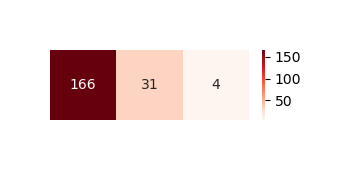

In [40]:
plot_count_strip([166, 31, 4], figsize=(2.86, 1), dataset_label="Radial Glia SOX2+PAX6+FABP7+", save=True)

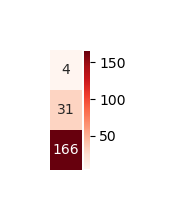

In [41]:
plot_count_strip([4, 31, 166], figsize=(1, 1.5), orientation='vertical', dataset_label="Radial Glia SOX2+PAX6+FABP7+", save=True)

<Figure size 1000x600 with 0 Axes>

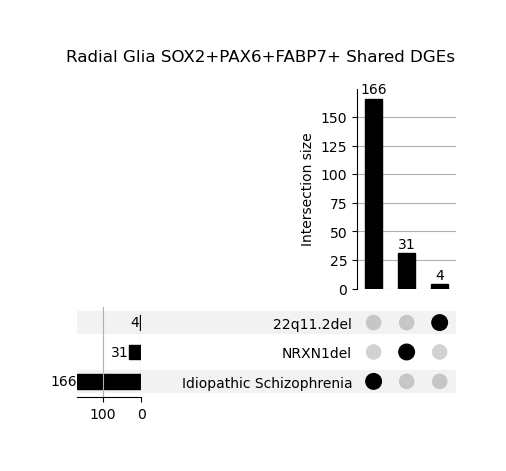

In [42]:
plot_assay_upset(dc_significant_all_rg_pax6, dataset_label="Radial Glia SOX2+PAX6+FABP7+", set_col='group')

<Figure size 1000x600 with 0 Axes>

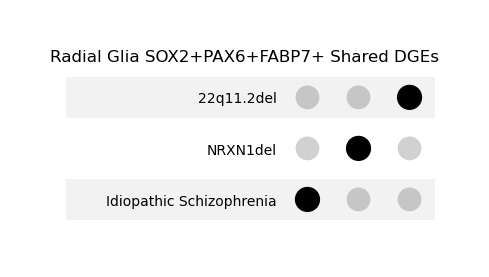

In [43]:
plot_assay_upset(dc_significant_all_rg_pax6,  dataset_label="Radial Glia SOX2+PAX6+FABP7+", 
                 set_col='group', top_graph=False, side_graph=False, save=True)

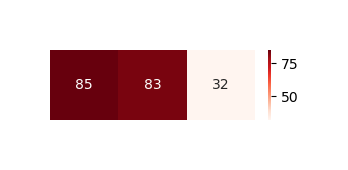

In [44]:
plot_count_strip([85, 83, 32], figsize=(2.86, 1), 
                 dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", save=True)

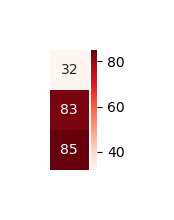

In [45]:
plot_count_strip([32, 83, 85], figsize=(1, 1.5), orientation='vertical', 
                 dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", save=True)

<Figure size 1000x600 with 0 Axes>

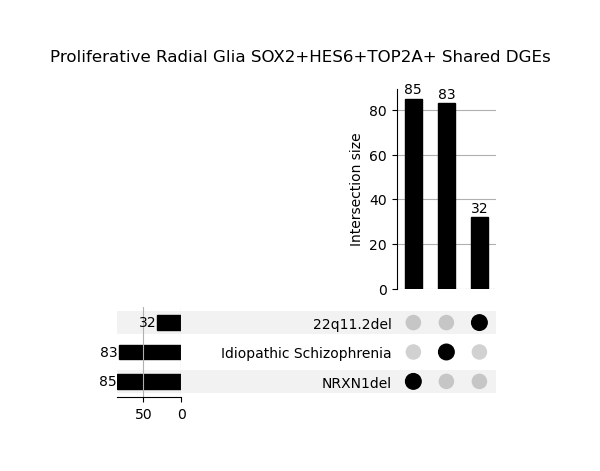

In [46]:
plot_assay_upset(dc_significant_all_prg, dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", set_col='group')

<Figure size 1000x600 with 0 Axes>

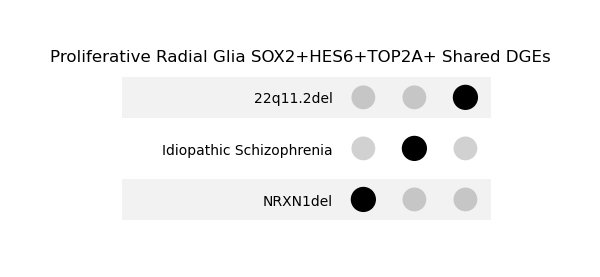

In [47]:
plot_assay_upset(dc_significant_all_prg, dataset_label="Proliferative Radial Glia SOX2+HES6+TOP2A+", 
                 set_col='group', top_graph=False, side_graph=False, save=True)

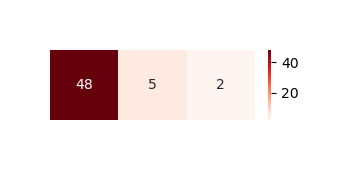

In [48]:
plot_count_strip([48, 5, 2], figsize=(2.86, 1), 
                 dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+", save=True)

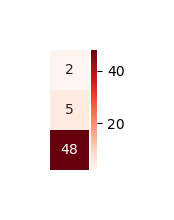

In [49]:
plot_count_strip([2, 5, 48], figsize=(1, 1.5), orientation='vertical', 
                 dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+", save=True)

<Figure size 1000x600 with 0 Axes>

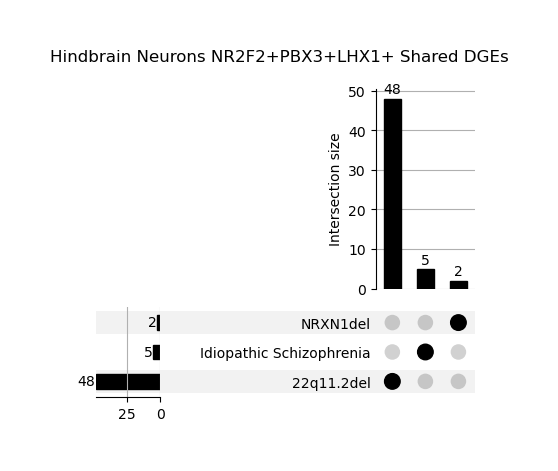

In [64]:
plot_assay_upset(dc_significant_all_hindbrain, dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+", set_col='group')

<Figure size 1000x600 with 0 Axes>

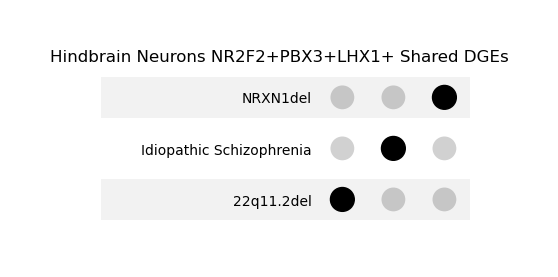

In [65]:
plot_assay_upset(dc_significant_all_hindbrain, dataset_label="Hindbrain Neurons NR2F2+PBX3+LHX1+",
                 set_col='group', top_graph=False, side_graph=False, save=True)

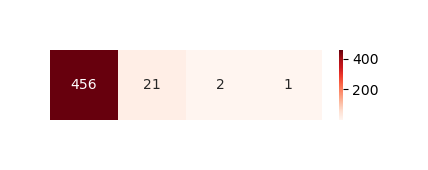

In [52]:
plot_count_strip([456, 21, 2, 1], figsize=(3.7, 1), 
                 dataset_label="Radial Glia SOX2+VIM+FABP7+", save=True)

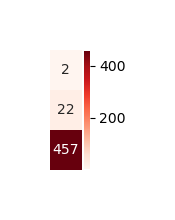

In [53]:
plot_count_strip([2, 22, 457], figsize=(1, 1.5), orientation='vertical', 
                 dataset_label="Radial Glia SOX2+VIM+FABP7+", save=True)

<Figure size 1000x600 with 0 Axes>

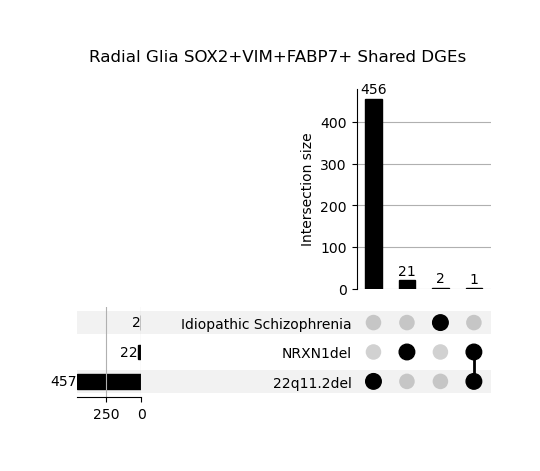

In [54]:
plot_assay_upset(dc_significant_all_rg_vim, dataset_label="Radial Glia SOX2+VIM+FABP7+", set_col='group')

<Figure size 1000x600 with 0 Axes>

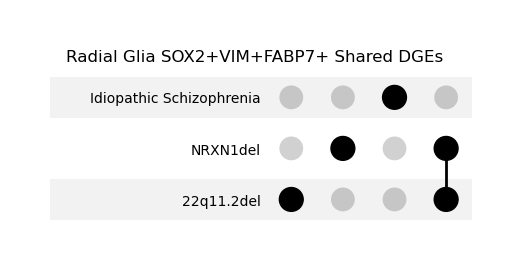

In [55]:
plot_assay_upset(dc_significant_all_rg_vim, dataset_label="Radial Glia SOX2+VIM+FABP7+", set_col='group',
                 top_graph=False, side_graph=False, save=True)

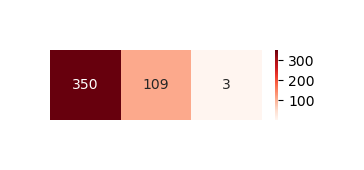

In [73]:
plot_count_strip([350, 109, 3], figsize=(3, 1), 
                 dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", save=True)

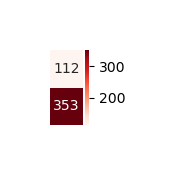

In [57]:
plot_count_strip([112, 353], figsize=(1, 1.05), orientation='vertical', 
                 dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", save=True)

<Figure size 1000x600 with 0 Axes>

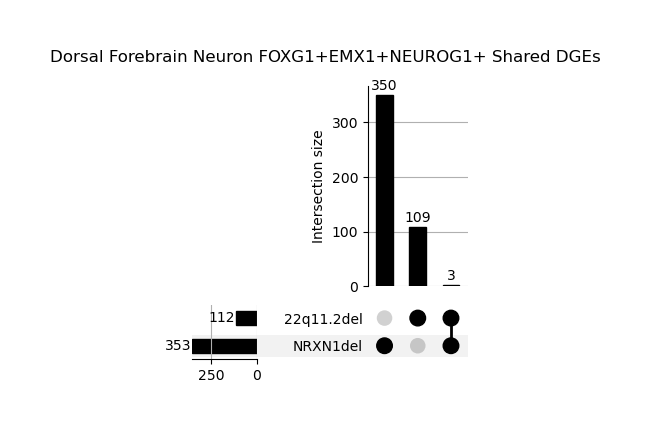

In [58]:
plot_assay_upset(dc_significant_all_dorsal, dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", set_col='group')

<Figure size 1000x600 with 0 Axes>

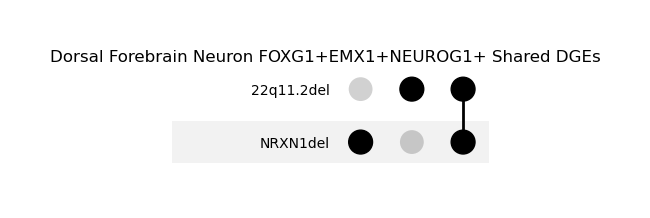

In [59]:
plot_assay_upset(dc_significant_all_dorsal, dataset_label="Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+",
                 set_col='group', top_graph=False, side_graph=False, save=True)

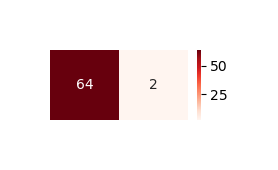

In [60]:
plot_count_strip([64, 2], figsize=(2.1, 1), 
                 dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+", save=True)

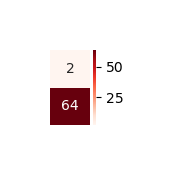

In [61]:
plot_count_strip([2, 64], figsize=(1, 1.05), orientation='vertical', 
                 dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+", save=True)

<Figure size 1000x600 with 0 Axes>

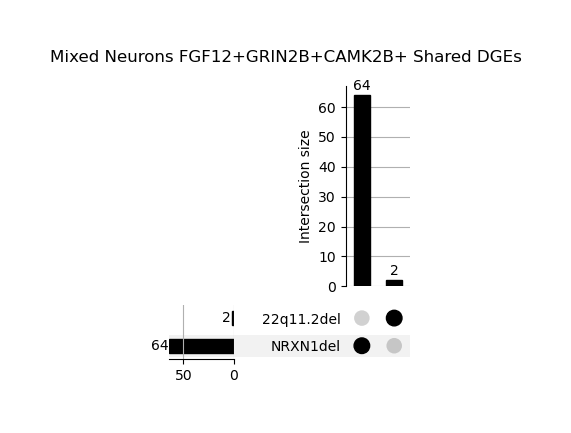

In [66]:
plot_assay_upset(dc_significant_all_mixed, dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+", set_col='group')

<Figure size 1000x600 with 0 Axes>

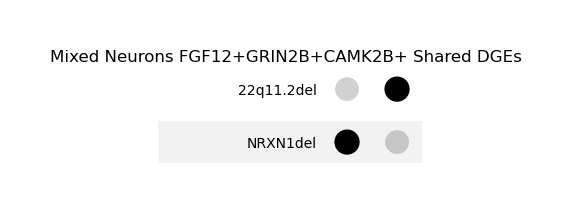

In [68]:
plot_assay_upset(dc_significant_all_mixed, dataset_label="Mixed Neurons FGF12+GRIN2B+CAMK2B+",  
                 set_col='group', top_graph=False, side_graph=False, save=True)

In [63]:
plot_assay_upset(dc_significant_all_mc, dataset_label="MC", set_col='group')

Not enough groups to plot: ['NRXN1del']


In [76]:
df_22q11_nrxn1[[i for i in df_22q11_nrxn1.columns if ('logFC' in i) or ('ID' in i)]]

,ID_22q11,assay_ID_22q11,logFC_rao_22q11,logFC_shin_22q11,logFC_walsh_22q11,mean_logFC_22q11,ID_nrxn1,assay_ID_nrxn1,logFC_sebastian_nrxn1,logFC_fernando_nrxn1,mean_logFC_nrxn1
0,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.810193,-0.437400,-0.550054,-0.599216,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.097236,0.485237,0.291237
1,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.567551,-0.055408,-0.592939,-0.405299,NBEA,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.253811,-1.403265,-0.828538
2,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.348741,-0.126931,-0.756534,-0.410735,NCOA2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,-0.351464,-0.765686,-0.558575
3,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,-0.351354,-1.405320,-1.151581,-0.969418,PIM1,Radial Glia SOX2+VIM+FABP7+ | PIM1,0.284833,1.638557,0.961695


/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


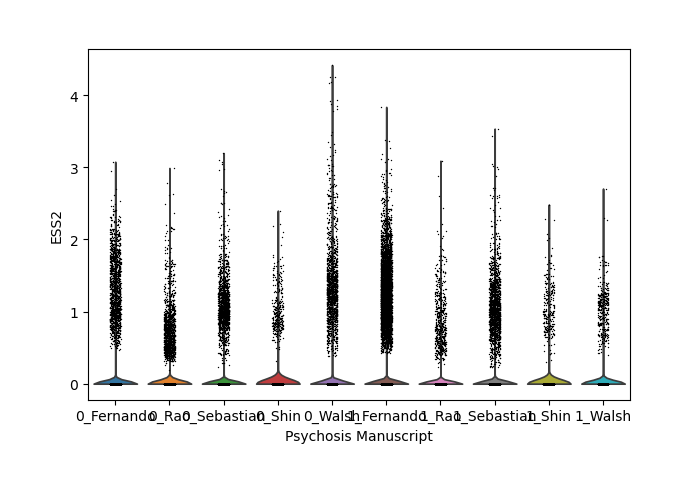

In [90]:
adata.obs['Psychosis_Manuscript'] = (adata.obs['Psychosis'].astype(str) + '_' + adata.obs['Manuscript'].astype(str))

sc.pl.violin(adata[(
    (adata.obs['subclass_annotations_markers'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+') &
    (adata.obs['Manuscript'].str.contains('Rao|Shin|Walsh|Sebastian|Fernando')) &
    (~adata.obs['Broad_Genotype'].str.contains('15q13'))
)], 
             keys='ESS2', groupby='Psychosis_Manuscript', stripplot=1)